# Analyse complète — Incremental vs Online_newjob vs Hybrid-n_j (2026-10-07)

Protocole single-decision-point : un état A gelé (n_existing jobs déjà en place, construit via un
vrai dispatch SimPy live), puis un nouveau job arrive à mi-vie du batch (max_flow_time/2 + 200).
Les 3 approches décident de son placement à partir du même état A figé, sans contamination entre
elles (vérifié).

- **Phase A** : 3 paliers de taille (petit/grand/mixte) à échelle x2 fixe, puis le palier mixte
  seul balayé en échelle x0.5/x2/x4/x6 — `n_existing=5` fixe, 50 nœuds.
- **Phase B** : palier mixte x2 fixe, `n_existing` ∈ {2,5,10,15} — 50 nœuds.
- **Phase C** : 5 scénarios totalement aléatoires (nb_nodes∈[10,30], n_existing∈[2,15], plages de
  taille/durée aléatoires), avec un plancher forçant le nouveau job à ne jamais être petit.

Budgets solveur : état A=30s, Incremental=défaut, Online_newjob=30s, Hybrid F1=15s +
escalade=30s (11 variantes concurrentes), plafond de dégradation=25%, mono-objectif
(`adaptive_bi_objective=False`).

In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("results-validation-2026-10-07/phaseABC_full_metrics.csv")
df = df[df.no_solution != True].copy()

APPROACH_DISPLAY = {"incremental": "Incremental", "online_newjob": "Online_newjob", "hybrid": "Hybrid-n_j"}
df["approach_disp"] = df["approach"].map(APPROACH_DISPLAY)
colors = {"Incremental": "#8C8C8C", "Online_newjob": "#4472C4", "Hybrid-n_j": "#2E8B57"}
order = ["Incremental", "Online_newjob", "Hybrid-n_j"]

PHASE_LABEL = {"A": "Phase A (palier/échelle)", "B": "Phase B (n_existing)", "C": "Phase C (aléatoire)"}
df["phase_label"] = df["phase"].map(PHASE_LABEL)

def scenario_label(row):
    if row.phase == "A":
        return f"{row.group}:{row.tag}"
    return row.tag

df["scenario"] = df.apply(scenario_label, axis=1)

def grouped_bar(ax, data, value_col, title, ylabel):
    scenarios = sorted(data["scenario"].unique(), key=lambda s: (len(s), s))
    x = np.arange(len(scenarios))
    width = 0.25
    for i, appr in enumerate(order):
        sub = data[data.approach_disp == appr].set_index("scenario").reindex(scenarios)[value_col]
        ax.bar(x + (i - 1) * width, sub.values, width, label=appr, color=colors[appr])
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=30, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

print(f"{len(df)} lignes chargées, phases: {sorted(df.phase.unique())}")
df.head()

48 lignes chargées, phases: ['A', 'B', 'C']


,phase,group,tag,n_existing,nb_nodes,new_job_dataset_size,new_job_nb_tasks,new_job_task_duration,dataset_size_range_lo,dataset_size_range_hi,...,data_transferred_new_job_mb,storage_violations,hybrid_f1,hybrid_escalation_budget,hybrid_accepted,hybrid_winning_variant,no_solution,approach_disp,phase_label,scenario
0,A,palier,petit,5,50,34903,18,282,4096,40960,...,314127,0,NaN,NaN,NaN,NaN,False,Incremental,Phase A (palier/échelle),palier:petit
1,A,palier,petit,5,50,34903,18,282,4096,40960,...,314127,0,NaN,NaN,NaN,NaN,False,Online_newjob,Phase A (palier/échelle),palier:petit
2,A,palier,petit,5,50,34903,18,282,4096,40960,...,314127,0,2106.0,NaN,False,freeze_below_mean,False,Hybrid-n_j,Phase A (palier/échelle),palier:petit
3,A,palier,grand,5,50,389472,19,594,204800,409600,...,2726304,0,NaN,NaN,NaN,NaN,False,Incremental,Phase A (palier/échelle),palier:grand
4,A,palier,grand,5,50,389472,19,594,204800,409600,...,3115776,0,NaN,NaN,NaN,NaN,False,Online_newjob,Phase A (palier/échelle),palier:grand


## 1. Flow time — nouveau job et reste du système

`flow_time_new_job` : la métrique principale (ce qu'on optimise).
`mean_flow_time_all` / `max_flow_time_all` : impact sur TOUS les jobs du batch reconsidéré —
Incremental ne touche jamais aux jobs existants, Online_newjob/Hybrid le peuvent (sous plafond de
dégradation de 25%).

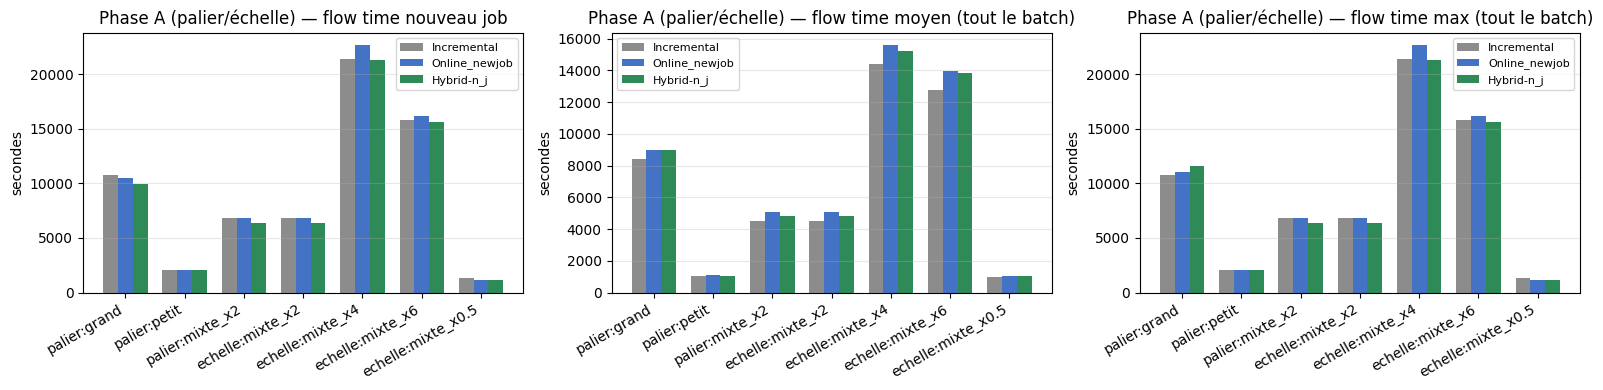

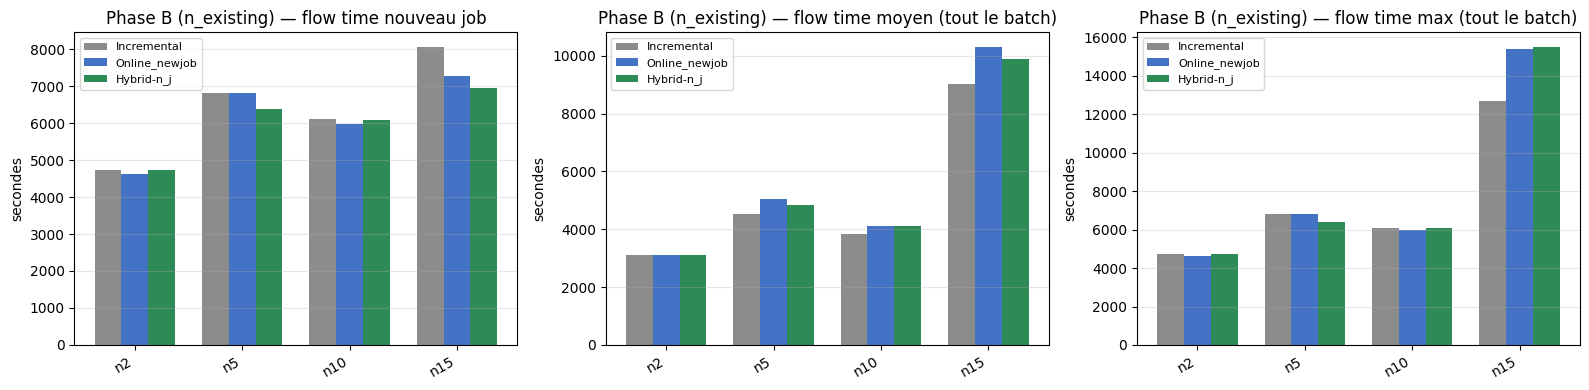

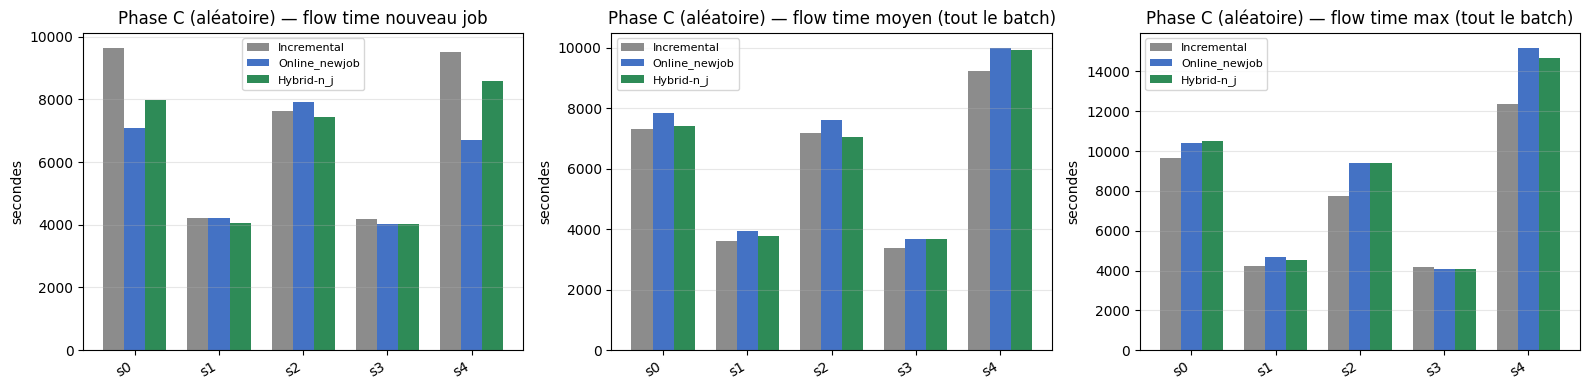

In [2]:
for phase in ["A", "B", "C"]:
    sub = df[df.phase == phase]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    grouped_bar(axes[0], sub, "flow_time_new_job", f"{PHASE_LABEL[phase]} — flow time nouveau job", "secondes")
    grouped_bar(axes[1], sub, "mean_flow_time_all", f"{PHASE_LABEL[phase]} — flow time moyen (tout le batch)", "secondes")
    grouped_bar(axes[2], sub, "max_flow_time_all", f"{PHASE_LABEL[phase]} — flow time max (tout le batch)", "secondes")
    plt.tight_layout()
    plt.show()

In [3]:
print("Gain Hybrid vs Incremental sur flow_time_new_job, par scénario :")
pivot = df.pivot_table(index=["phase", "scenario"], columns="approach", values="flow_time_new_job")
pivot["gain_hybrid_pct"] = (pivot["incremental"] - pivot["hybrid"]) / pivot["incremental"] * 100
pivot["gain_online_newjob_pct"] = (pivot["incremental"] - pivot["online_newjob"]) / pivot["incremental"] * 100
pivot.round(1)

Gain Hybrid vs Incremental sur flow_time_new_job, par scénario :


approach                   hybrid  incremental  online_newjob  \
phase scenario                                                  
A     echelle:mixte_x0.5   1131.0       1351.0         1131.0   
      echelle:mixte_x2     6379.0       6816.0         6817.0   
      echelle:mixte_x4    21285.0      21414.0        22660.0   
      echelle:mixte_x6    15581.0      15812.0        16192.0   
      palier:grand         9946.0      10799.0        10530.0   
      palier:mixte_x2      6379.0       6816.0         6817.0   
      palier:petit         2106.0       2106.0         2107.0   
B     n10                  6091.0       6099.0         5967.0   
      n15                  6953.0       8050.0         7261.0   
      n2                   4730.0       4730.0         4633.0   
      n5                   6379.0       6816.0         6817.0   
C     s0                   7987.0       9641.0         7081.0   
      s1                   4072.0       4206.0         4204.0   
      s2                   7442.0       7640.0         7931.0   
      s3                   4009.0       4184.0         4009.0   
      s4                   8575.0       9520.0         6713.0   

approach                  gain_hybrid_pct  gain_online_newjob_pct  
phase scenario                                                     
A     echelle:mixte_x0.5             16.3                    16.3  
      echelle:mixte_x2                6.4                    -0.0  
      echelle:mixte_x4                0.6                    -5.8  
      echelle:mixte_x6                1.5                    -2.4  
      palier:grand                    7.9                     2.5  
      palier:mixte_x2                 6.4                    -0.0  
      palier:petit                    0.0                    -0.0  
B     n10                             0.1                     2.2  
      n15                            13.6                     9.8  
      n2                              0.0                     2.1  
      n5                              6.4                    -0.0  
C     s0                             17.2                    26.6  
      s1                              3.2                     0.0  
      s2                              2.6                    -3.8  
      s3                              4.2                     4.2  
      s4                              9.9                    29.5

## 2. Nombre de transferts

`nb_transfers_new_job` : combien de répliques (nœuds différents) le nouveau job reçoit — un
chiffre élevé signifie que l'approche étale ses tâches sur plus de nœuds en parallèle.
`nb_transfers_total` : tous les transferts du plan proposé (nouveau job + jobs reconsidérés).

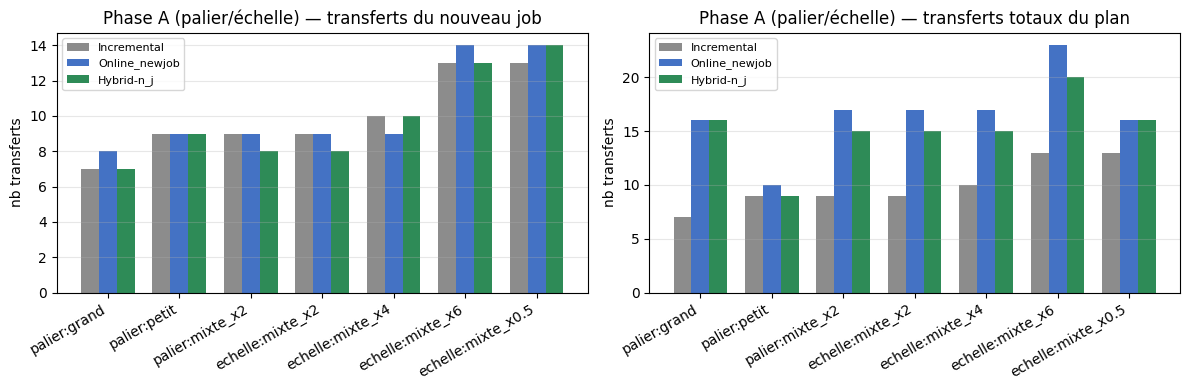

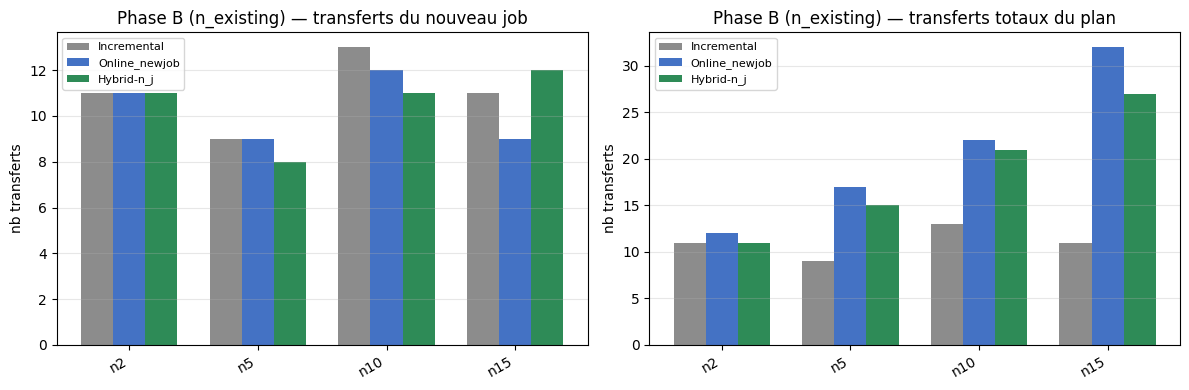

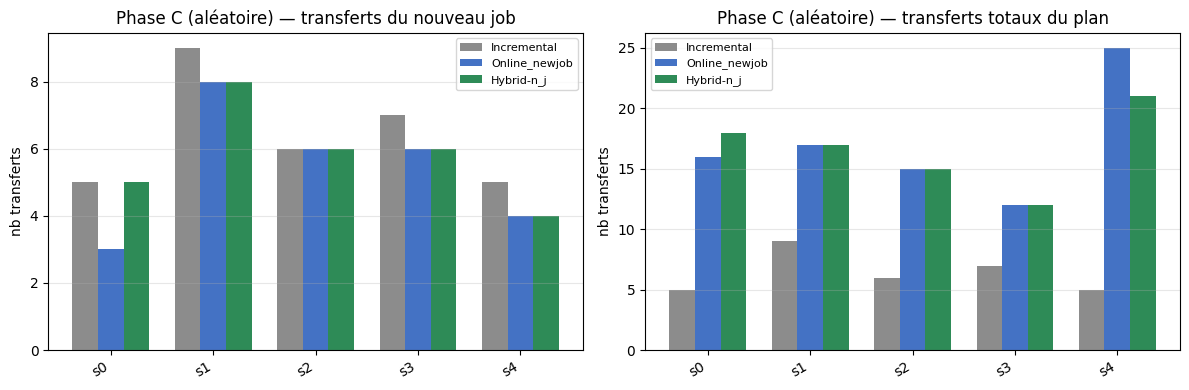

In [4]:
for phase in ["A", "B", "C"]:
    sub = df[df.phase == phase]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    grouped_bar(axes[0], sub, "nb_transfers_new_job", f"{PHASE_LABEL[phase]} — transferts du nouveau job", "nb transferts")
    grouped_bar(axes[1], sub, "nb_transfers_total", f"{PHASE_LABEL[phase]} — transferts totaux du plan", "nb transferts")
    plt.tight_layout()
    plt.show()

## 3. Nombre de nœuds utilisés

`nb_nodes_used_new_job` : sur combien de nœuds distincts le nouveau job est étalé.
`nb_nodes_used_total` : nœuds actifs dans tout le plan proposé (reflète combien de nœuds
Online_newjob/Hybrid retouchent quand ils reconsidèrent les jobs existants).

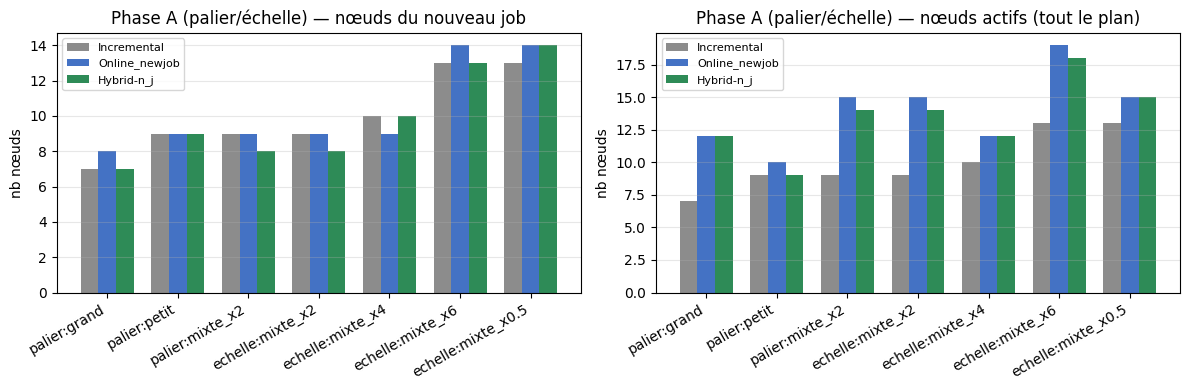

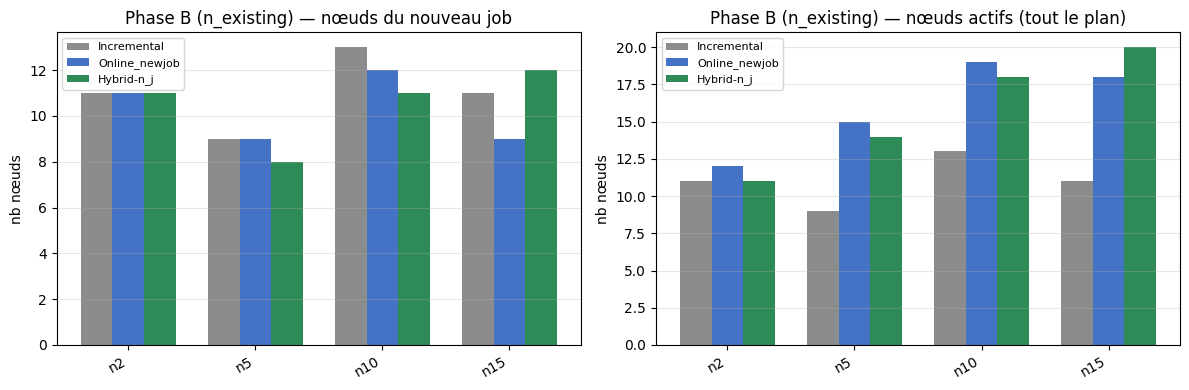

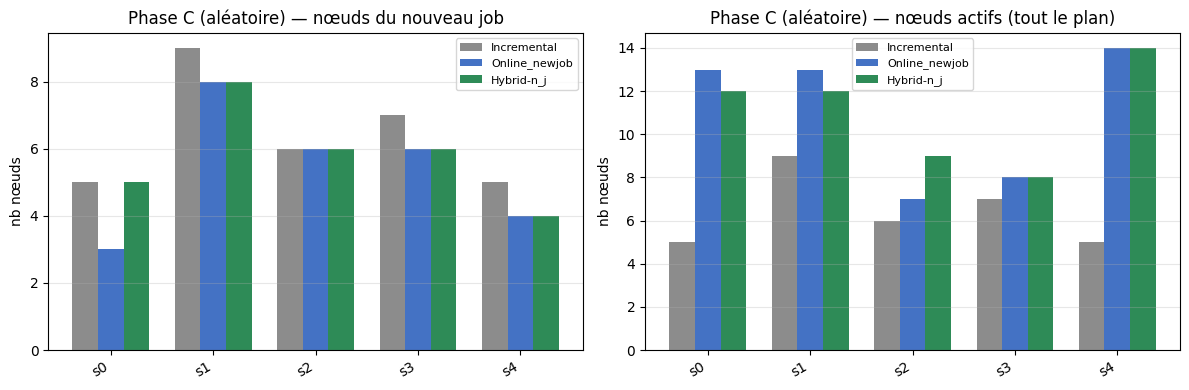

In [5]:
for phase in ["A", "B", "C"]:
    sub = df[df.phase == phase]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    grouped_bar(axes[0], sub, "nb_nodes_used_new_job", f"{PHASE_LABEL[phase]} — nœuds du nouveau job", "nb nœuds")
    grouped_bar(axes[1], sub, "nb_nodes_used_total", f"{PHASE_LABEL[phase]} — nœuds actifs (tout le plan)", "nb nœuds")
    plt.tight_layout()
    plt.show()

## 4. Quantité de données transférées (nouveau job)

`data_transferred_new_job_mb` = nb_transfers_new_job × taille du dataset du nouveau job — le
volume réseau que chaque approche génère pour PLACER le nouveau job (pas le reste du batch).

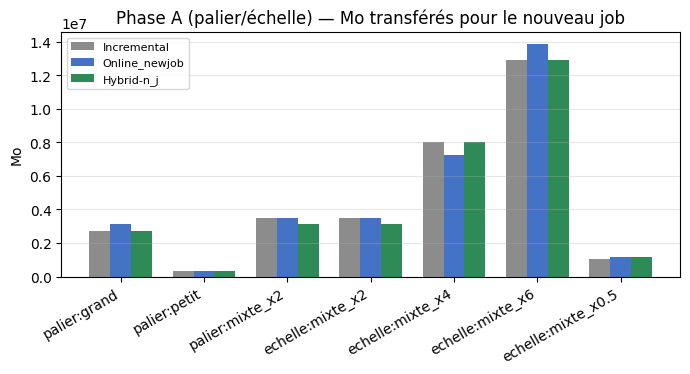

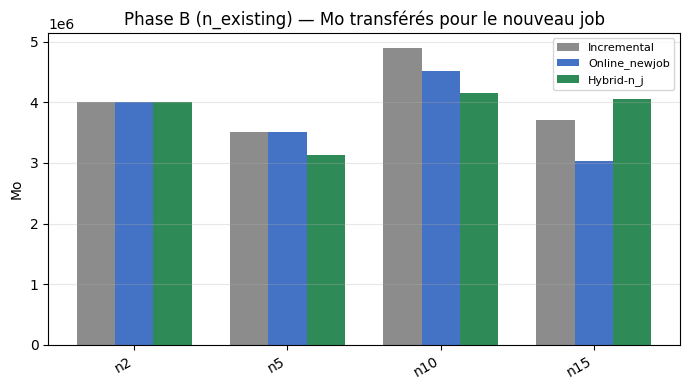

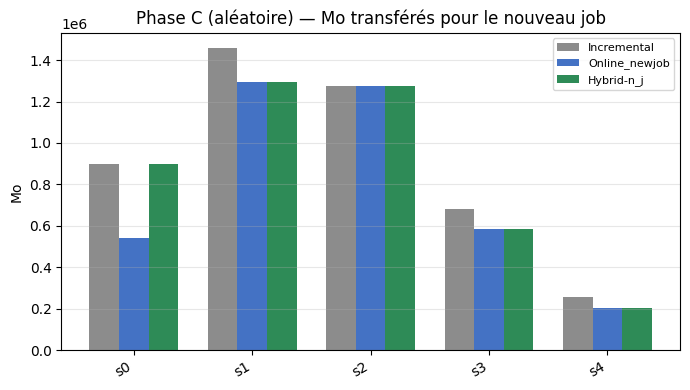

In [6]:
for phase in ["A", "B", "C"]:
    sub = df[df.phase == phase]
    fig, ax = plt.subplots(figsize=(7, 4))
    grouped_bar(ax, sub, "data_transferred_new_job_mb", f"{PHASE_LABEL[phase]} — Mo transférés pour le nouveau job", "Mo")
    plt.tight_layout()
    plt.show()

## 5. Énergie de transfert

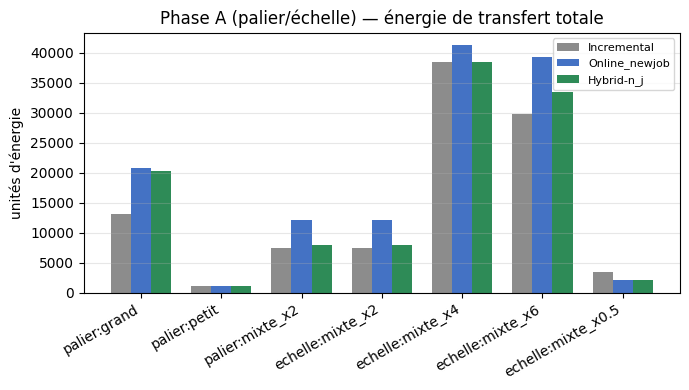

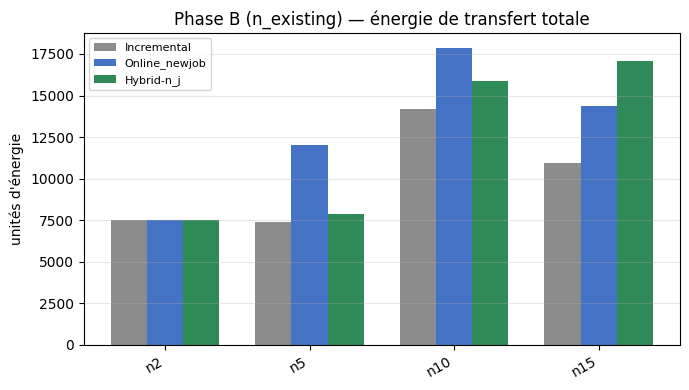

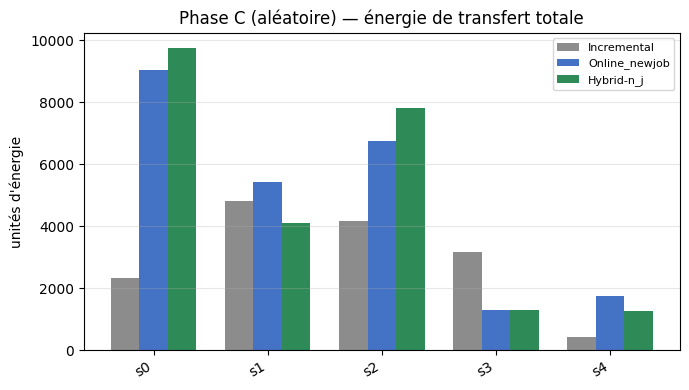

In [7]:
for phase in ["A", "B", "C"]:
    sub = df[df.phase == phase]
    fig, ax = plt.subplots(figsize=(7, 4))
    grouped_bar(ax, sub, "transfer_energy_total", f"{PHASE_LABEL[phase]} — énergie de transfert totale", "unités d'énergie")
    plt.tight_layout()
    plt.show()

## 6. Temps de scheduling (mur)

Temps réel passé à résoudre (pas de temps simulé ici, protocole figé). Hybrid inclut la sonde F1
+ l'escalade (jusqu'à 11 variantes concurrentes).

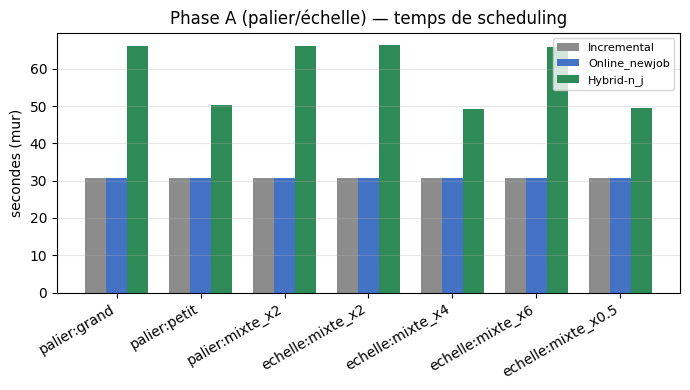

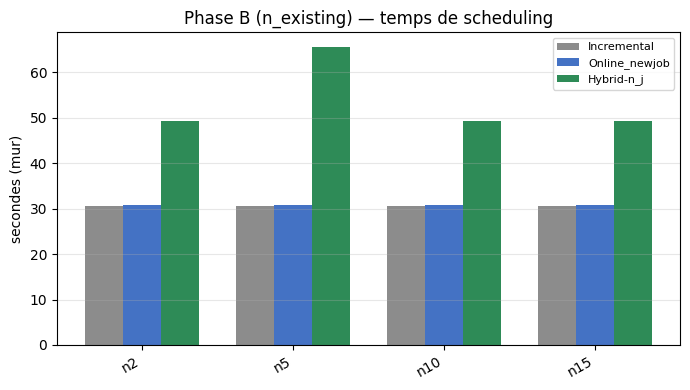

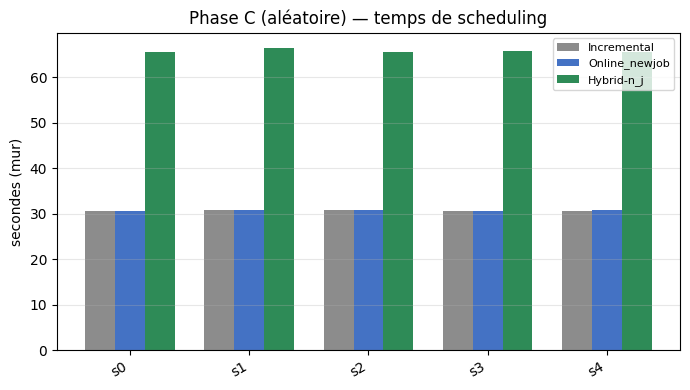

In [8]:
for phase in ["A", "B", "C"]:
    sub = df[df.phase == phase]
    fig, ax = plt.subplots(figsize=(7, 4))
    grouped_bar(ax, sub, "scheduling_time_s", f"{PHASE_LABEL[phase]} — temps de scheduling", "secondes (mur)")
    plt.tight_layout()
    plt.show()

## 7. Variantes gagnantes d'Hybrid-n_j

Quelle variante d'escalade (sur les 11 concurrentes) a été retenue à chaque fois, et taux
d'acceptation de l'escalade (vs rejet/fallback sur F1=Incremental).

In [9]:
hyb = df[df.approach == "hybrid"].copy()
print("Taux d'acceptation de l'escalade :", f"{hyb.hybrid_accepted.mean()*100:.0f}%", f"({hyb.hybrid_accepted.sum()}/{len(hyb)})")
print()
print("Distribution des variantes gagnantes (quand acceptée) :")
hyb[hyb.hybrid_accepted == True].hybrid_winning_variant.value_counts()

Taux d'acceptation de l'escalade : 88% (14/16)

Distribution des variantes gagnantes (quand acceptée) :


hybrid_winning_variant
freeze_above_mean    4
freeze_below_mean    3
nofreeze             2
greedy_hints         2
warm_nofreeze        1
hint_slow_to_fast    1
hint_from_f1         1
Name: count, dtype: int64

/var/folders/dv/9p4r1chx4gd236cc70dc2zf00000gp/T/ipykernel_67263/2158886751.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=30, ha="right")


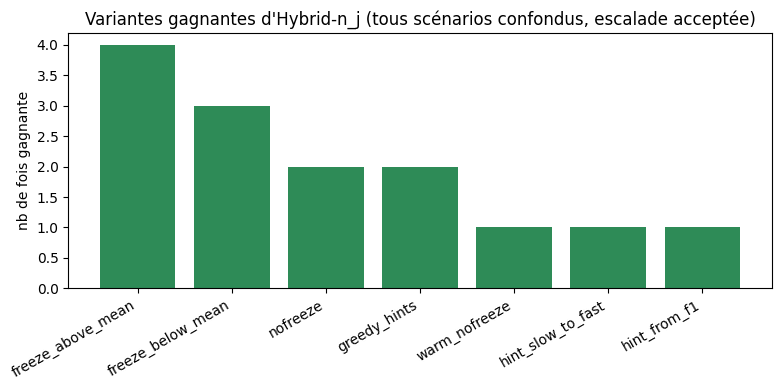

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = hyb[hyb.hybrid_accepted == True].hybrid_winning_variant.value_counts()
ax.bar(counts.index, counts.values, color="#2E8B57")
ax.set_xticklabels(counts.index, rotation=30, ha="right")
ax.set_title("Variantes gagnantes d'Hybrid-n_j (tous scénarios confondus, escalade acceptée)")
ax.set_ylabel("nb de fois gagnante")
plt.tight_layout()
plt.show()

In [11]:
hyb[["phase", "scenario", "hybrid_accepted", "hybrid_winning_variant", "flow_time_new_job", "hybrid_f1"]]

,phase,scenario,hybrid_accepted,hybrid_winning_variant,flow_time_new_job,hybrid_f1
2,A,palier:petit,False,freeze_below_mean,2106.0,2106.0
5,A,palier:grand,True,warm_nofreeze,9946.0,10799.0
8,A,palier:mixte_x2,True,freeze_above_mean,6379.0,6816.0
11,A,echelle:mixte_x0.5,True,freeze_below_mean,1131.0,1351.0
14,A,echelle:mixte_x2,True,freeze_above_mean,6379.0,6816.0
17,A,echelle:mixte_x4,True,freeze_above_mean,21285.0,21414.0
20,A,echelle:mixte_x6,True,freeze_below_mean,15581.0,19812.0
23,B,n2,False,freeze_below_mean,4730.0,4730.0
26,B,n5,True,freeze_above_mean,6379.0,6816.0
29,B,n10,True,nofreeze,6091.0,6099.0


## 8. Violations de stockage (vérification du plan proposé)

Contrairement au protocole live, le plan proposé ici n'est jamais réellement dispatché -- cette
vérification reconstruit l'occupation (stockage fantôme des autres jobs + transferts/suppressions
du plan) et compare à la capacité réelle de chaque nœud, exactement comme `verify_storage()` le
fait pour la simulation live.

In [12]:
print("Violations de stockage par approche (somme sur tous les scénarios) :")
df.groupby("approach_disp").storage_violations.sum()

Violations de stockage par approche (somme sur tous les scénarios) :


approach_disp
Hybrid-n_j       0
Incremental      0
Online_newjob    0
Name: storage_violations, dtype: int64

## 9. Évolution de la complexité du problème

`batch_size` = nombre de jobs reconsidérés dans ce solve (1 pour Incremental, toujours ; nouveau
job + jobs existants non finis pour Online_newjob/Hybrid). On regarde comment le temps de
scheduling et le gain évoluent avec cette taille de batch et avec `n_existing`/l'échelle.

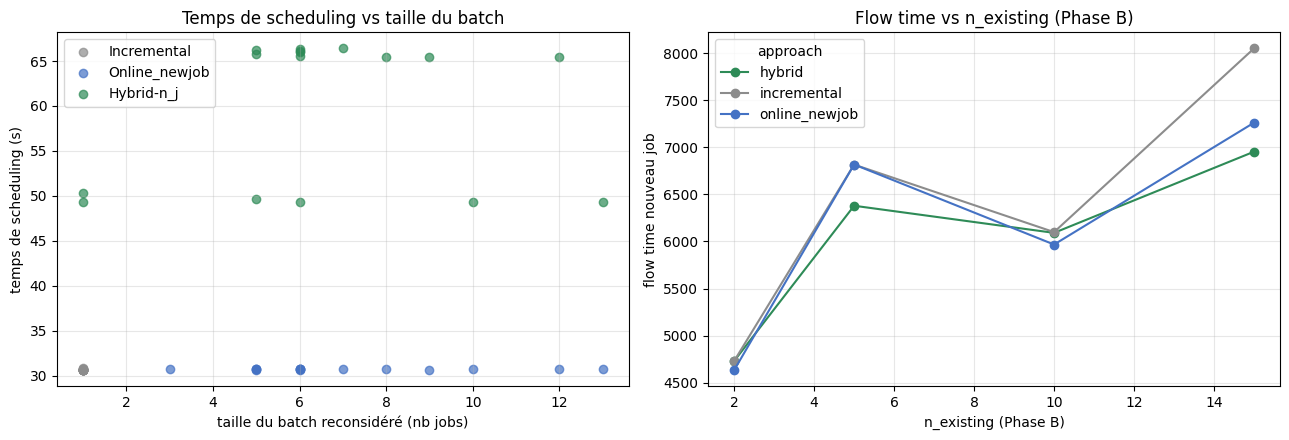

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for appr in order:
    sub = df[df.approach_disp == appr]
    axes[0].scatter(sub.batch_size, sub.scheduling_time_s, label=appr, color=colors[appr], alpha=0.7)
axes[0].set_xlabel("taille du batch reconsidéré (nb jobs)")
axes[0].set_ylabel("temps de scheduling (s)")
axes[0].set_title("Temps de scheduling vs taille du batch")
axes[0].legend()
axes[0].grid(alpha=0.3)

b = df[df.phase == "B"].pivot_table(index="n_existing", columns="approach", values="flow_time_new_job")
b.plot(ax=axes[1], marker="o", color=[colors[APPROACH_DISPLAY[c]] for c in b.columns])
axes[1].set_xlabel("n_existing (Phase B)")
axes[1].set_ylabel("flow time nouveau job")
axes[1].set_title("Flow time vs n_existing (Phase B)")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

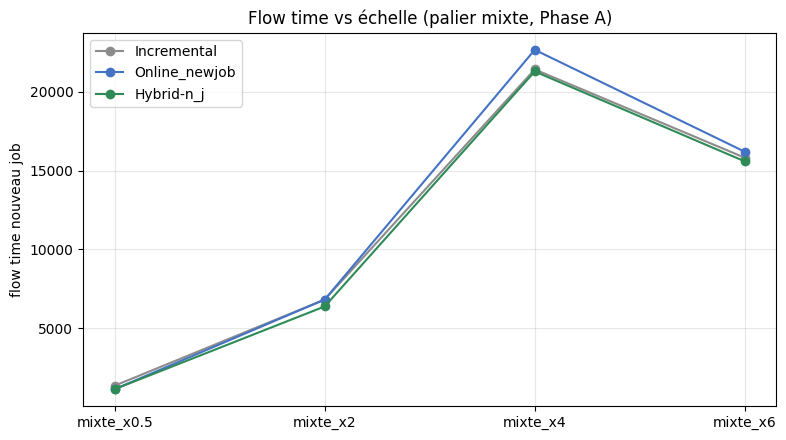

In [14]:
scale_order = ["mixte_x0.5", "mixte_x2", "mixte_x4", "mixte_x6"]
a = df[(df.phase == "A") & (df.group == "echelle")].copy()
a["tag"] = pd.Categorical(a.tag, categories=scale_order, ordered=True)
a = a.sort_values("tag")
fig, ax = plt.subplots(figsize=(8, 4.5))
for appr in order:
    sub = a[a.approach_disp == appr]
    ax.plot(sub.tag.astype(str), sub.flow_time_new_job, marker="o", label=appr, color=colors[appr])
ax.set_title("Flow time vs échelle (palier mixte, Phase A)")
ax.set_ylabel("flow time nouveau job")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Synthèse générale par phase

In [15]:
summary = df.groupby(["phase", "approach_disp"]).agg(
    flow_time_new_job_mean=("flow_time_new_job", "mean"),
    scheduling_time_s_mean=("scheduling_time_s", "mean"),
    transfer_energy_mean=("transfer_energy_total", "mean"),
    nb_transfers_new_job_mean=("nb_transfers_new_job", "mean"),
    nb_nodes_used_new_job_mean=("nb_nodes_used_new_job", "mean"),
    storage_violations_sum=("storage_violations", "sum"),
).round(1)
summary

flow_time_new_job_mean  scheduling_time_s_mean  \
phase approach_disp                                                   
A     Hybrid-n_j                     8972.4                    59.1   
      Incremental                    9302.0                    30.7   
      Online_newjob                  9464.9                    30.7   
B     Hybrid-n_j                     6038.2                    53.4   
      Incremental                    6423.8                    30.7   
      Online_newjob                  6169.5                    30.7   
C     Hybrid-n_j                     6417.0                    65.7   
      Incremental                    7038.2                    30.7   
      Online_newjob                  5987.6                    30.7   

                     transfer_energy_mean  nb_transfers_new_job_mean  \
phase approach_disp                                                    
A     Hybrid-n_j                  15877.2                        9.9   
      Incremental                 14359.5                       10.0   
      Online_newjob               18347.4                       10.3   
B     Hybrid-n_j                  12098.4                       10.5   
      Incremental                 10010.7                       11.0   
      Online_newjob               12954.7                       10.2   
C     Hybrid-n_j                   4838.5                        5.8   
      Incremental                  2983.5                        6.4   
      Online_newjob                4856.3                        5.4   

                     nb_nodes_used_new_job_mean  storage_violations_sum  
phase approach_disp                                                      
A     Hybrid-n_j                            9.9                       0  
      Incremental                          10.0                       0  
      Online_newjob                        10.3                       0  
B     Hybrid-n_j                           10.5                       0  
      Incremental                          11.0                       0  
      Online_newjob                        10.2                       0  
C     Hybrid-n_j                            5.8                       0  
      Incremental                           6.4                       0  
      Online_newjob                         5.4                       0

### Points clés

- **Hybrid-n_j** égale ou bat Incremental sur `flow_time_new_job` dans la quasi-totalité des
  scénarios (jamais pire, grâce à son filet de sécurité F1), au prix d'un temps de scheduling et
  d'une énergie plus élevés.
- **Online_newjob** seul peut être pire qu'Incremental (observé en Phase A à grande échelle et en
  Phase C) — il n'a pas de filet de sécurité, contrairement à Hybrid.
- Aucune violation de stockage détectée pour aucune des 3 approches dans ce protocole figé
  (single-decision-point) — à l'inverse du protocole live (simulation continue Poisson), où Hybrid
  seul en a montré (voir note séparée sur l'expérience Poisson du 2026-10-07).